# Optimización de rendimiento en Python

**Python Profesional para Analítica Avanzada · CaixaBank Advanced Analytics Program**

## Del pipeline correcto al pipeline medido

El informe de operaciones ya es correcto y trazable. Al ejecutar el cierre mensual tarda demasiado. Hoy seguiremos un ciclo completo: **medir → localizar → cambiar → comprobar**.

## Qué haremos

Primero optimizaremos juntos el cálculo de importe del informe. Después aplicarás el mismo razonamiento a una regla de prioridad.

Al acabar podrás demostrar tres cosas: qué operación dominaba el coste, cuánto mejora la nueva versión y que el resultado no ha cambiado.

In [1]:
import cProfile
import io
import pstats
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.testing import assert_frame_equal

sns.set_theme(style='whitegrid', palette='deep')
SEED = 42

def generar_operaciones(n=80_000, seed=SEED):
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        'operacion_id': np.arange(1, n + 1),
        'region': rng.choice(['norte', 'centro', 'este', 'sur'], n),
        'canal': rng.choice(['movil', 'web', 'oficina'], n),
        'unidades': rng.integers(1, 10, n),
        'precio': rng.uniform(5, 300, n),
        'descuento': rng.choice([0.0, 0.05, 0.10, 0.20], n),
    })

operaciones = generar_operaciones()
operaciones.head()

,operacion_id,region,canal,unidades,precio,descuento
0,1,norte,web,9,183.608056,0.20
1,2,sur,movil,6,220.985424,0.05
2,3,este,movil,1,271.976304,0.20
3,4,centro,movil,2,15.299447,0.05
4,5,centro,movil,7,91.822421,0.05


## Herramientas de la sesión

- `medir(funcion)` ejecuta la misma función varias veces y devuelve mediana, dispersión y todos los tiempos. Usaremos la **mediana** para comparar versiones.
- `cProfile` indica dónde se acumula el tiempo; no cambia el código.
- `assert_frame_equal(tabla_a, tabla_b)` comprueba que dos DataFrames son iguales.
- `np.where(condicion, valor_si, valor_no)` crea una columna a partir de una condición sobre una Serie completa.

In [2]:
def medir(funcion, repeticiones=7, calentamiento=1):
    for _ in range(calentamiento):
        funcion()
    tiempos = []
    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        tiempos.append(time.perf_counter() - inicio)
    tiempos = np.array(tiempos)
    return {'mediana_ms': np.median(tiempos) * 1_000, 'std_ms': tiempos.std() * 1_000, 'raw_ms': tiempos * 1_000}

def mostrar_perfil(funcion, lineas=10):
    perfil = cProfile.Profile()
    perfil.enable(); funcion(); perfil.disable()
    salida = io.StringIO()
    pstats.Stats(perfil, stream=salida).sort_stats('cumulative').print_stats(lineas)
    print(salida.getvalue())

def graficar_comparacion(medidas, titulo, grupo=None):
    """Compara medianas de versiones lenta y optimizada con Seaborn."""
    tabla = pd.DataFrame(medidas)
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    sns.barplot(data=tabla, x=grupo or 'version', y='mediana_ms', hue='version' if grupo else None, palette=['#d95f59', '#0077b6'], ax=ax)
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f ms', padding=4, fontsize=10)
    ax.set(title=titulo, ylabel='Mediana de tiempo (ms)', xlabel='')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=.25)
    fig.tight_layout()
    plt.show()

## 1. Síntoma: un cálculo correcto, pero fila a fila

La función siguiente calcula el importe correctamente, pero usa `apply(axis=1)`: llama a Python una vez por cada operación.

In [3]:
def importe_lento(datos):
    salida = datos.copy()
    salida['importe'] = salida.apply(
        lambda fila: fila['unidades'] * fila['precio'] * (1 - fila['descuento']), axis=1
    )
    return salida

def informe_por_region(datos, calcular_importe):
    calculadas = calcular_importe(datos)
    return (calculadas.groupby(['region', 'canal'], as_index=False)
            .agg(operaciones=('operacion_id', 'size'), importe_total=('importe', 'sum'))
            .sort_values(['region', 'canal']).reset_index(drop=True))

baseline_lento = medir(lambda: informe_por_region(operaciones, importe_lento))
pd.Series({k: v for k, v in baseline_lento.items() if k != 'raw_ms'})

mediana_ms    171.236708
std_ms          2.566779
dtype: float64

## 2. Evidencia: localizar el coste dominante

Ejecuta el perfil. Busca `apply` y observa su tiempo acumulado (`cumtime`). Esa evidencia justifica cambiar el cálculo del importe antes que cualquier otra parte del informe.

In [4]:
mostrar_perfil(lambda: informe_por_region(operaciones, importe_lento))

         4415189 function calls (4414838 primitive calls) in 0.597 seconds

   Ordered by: cumulative time
   List reduced from 765 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.000    0.000    0.597    0.597 /var/folders/3z/w0gc4qzj2_v1qf_lvky61n6w0000gn/T/ipykernel_93529/92980967.py:1(<lambda>)
        1    0.000    0.000    0.597    0.597 /var/folders/3z/w0gc4qzj2_v1qf_lvky61n6w0000gn/T/ipykernel_93529/1849324507.py:8(informe_por_region)
        1    0.002    0.002    0.590    0.590 /var/folders/3z/w0gc4qzj2_v1qf_lvky61n6w0000gn/T/ipykernel_93529/1849324507.py:1(importe_lento)
        1    0.000    0.000    0.588    0.588 /Users/andrea/Library/CloudStorage/SynologyDrive-Dory/classes/postgrau/Python Profesional para Analtica Avanzada/.venv/lib/python3.14/site-packages/pandas/core/frame.py:12202(apply)
        1    0.001    0.001    0.588    0.588 /Users/andrea/Library/CloudStorage/SynologyDrive-Dory/classes/postg

### Cómo leer cProfile

| Campo | Lectura práctica |
|---|---|
| ncalls | Cuántas veces se llama a la función. |
| tottime | Tiempo dentro de la función, sin sus llamadas internas. |
| percall | Tiempo medio por llamada; aparece dos veces porque puede referirse a tottime o cumtime. |
| cumtime | Tiempo acumulado de la función y todo lo que ejecuta. |
| filename:lineno(function) | Dónde está la función medida. |

Ordenamos por cumtime porque buscamos una causa de coste en el flujo completo, no solo una línea aislada.

## 3. Cambio guiado: una expresión sobre columnas completas

La fórmula es exactamente la misma. La diferencia es que Pandas multiplica Series completas en lugar de llamar a una función por fila.

In [5]:
def importe_vectorizado(datos):
    salida = datos.copy()
    salida['importe'] = salida['unidades'] * salida['precio'] * (1 - salida['descuento'])
    return salida

baseline_vectorizado = medir(lambda: informe_por_region(operaciones, importe_vectorizado))
resultado_lento = informe_por_region(operaciones, importe_lento)
resultado_vectorizado = informe_por_region(operaciones, importe_vectorizado)
assert_frame_equal(resultado_lento, resultado_vectorizado)

speedup_importe = baseline_lento['mediana_ms'] / baseline_vectorizado['mediana_ms']
pd.DataFrame([{
    'version': 'apply(axis=1)', 'mediana_ms': baseline_lento['mediana_ms']
}, {
    'version': 'vectorizada', 'mediana_ms': baseline_vectorizado['mediana_ms']
}, {
    'version': 'speedup', 'mediana_ms': speedup_importe
}])

,version,mediana_ms
0,apply(axis=1),171.236708
1,vectorizada,4.260041
2,speedup,40.196023


## 4. Ver la mejora y comprobar la escala

La misma función de Seaborn compara las medianas. Después repetimos la medición con varias cargas: la gráfica es evidencia observada, no una demostración formal de Big-O.

<positron-console-cell-6>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



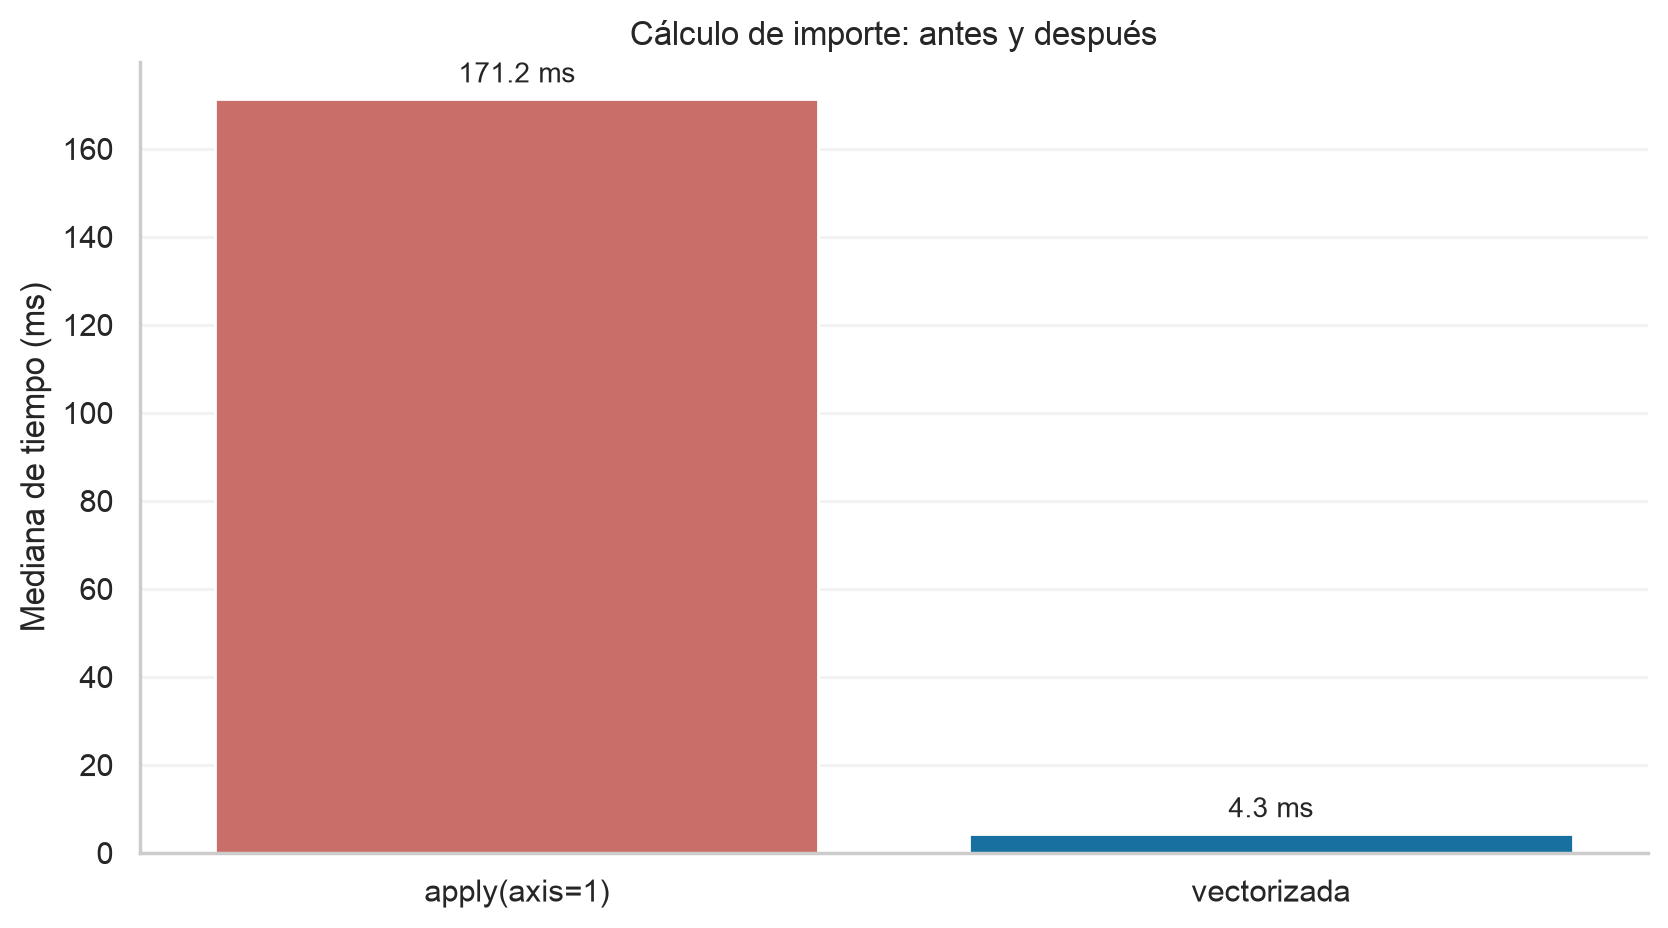

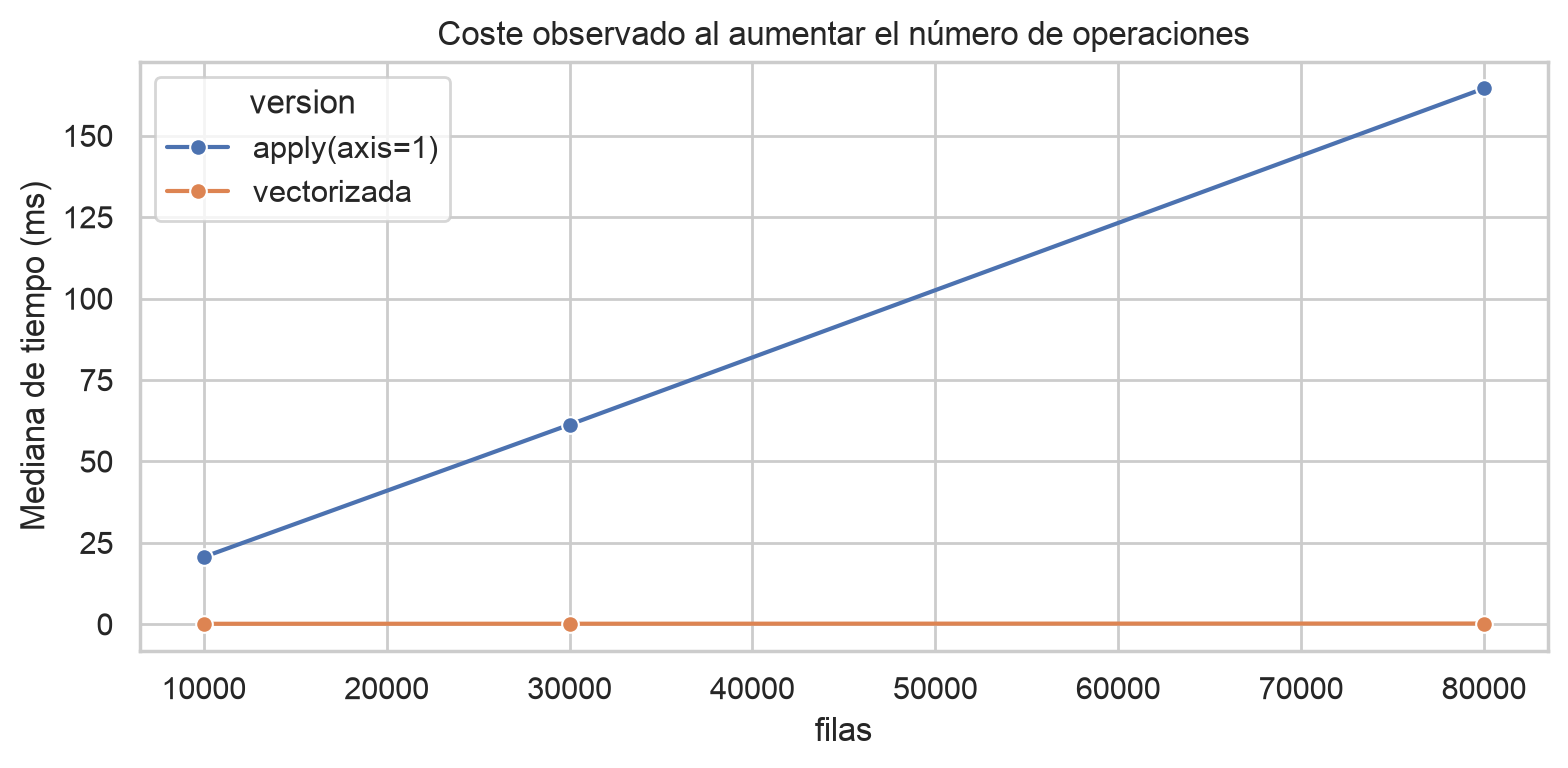

In [6]:
comparacion_importe = [
    {'version': 'apply(axis=1)', 'mediana_ms': baseline_lento['mediana_ms']},
    {'version': 'vectorizada', 'mediana_ms': baseline_vectorizado['mediana_ms']},
]
graficar_comparacion(comparacion_importe, 'Cálculo de importe: antes y después')

escalabilidad = []
for filas in [10_000, 30_000, 80_000]:
    muestra = generar_operaciones(filas, seed=SEED)
    for version, funcion in [('apply(axis=1)', importe_lento), ('vectorizada', importe_vectorizado)]:
        escalabilidad.append({'filas': filas, 'version': version, 'mediana_ms': medir(lambda f=funcion, d=muestra: f(d))['mediana_ms']})

tabla_escalabilidad = pd.DataFrame(escalabilidad)
plt.figure(figsize=(8, 4))
sns.lineplot(data=tabla_escalabilidad, x='filas', y='mediana_ms', hue='version', marker='o')
plt.title('Coste observado al aumentar el número de operaciones')
plt.ylabel('Mediana de tiempo (ms)')
plt.tight_layout()
plt.show()

## 5. Una función no es todo el pipeline

La mejora del cálculo no elimina el coste de agregar y ordenar el informe. Por eso la siguiente sesión estudiará memoria, copias y datos innecesarios, además del tiempo.

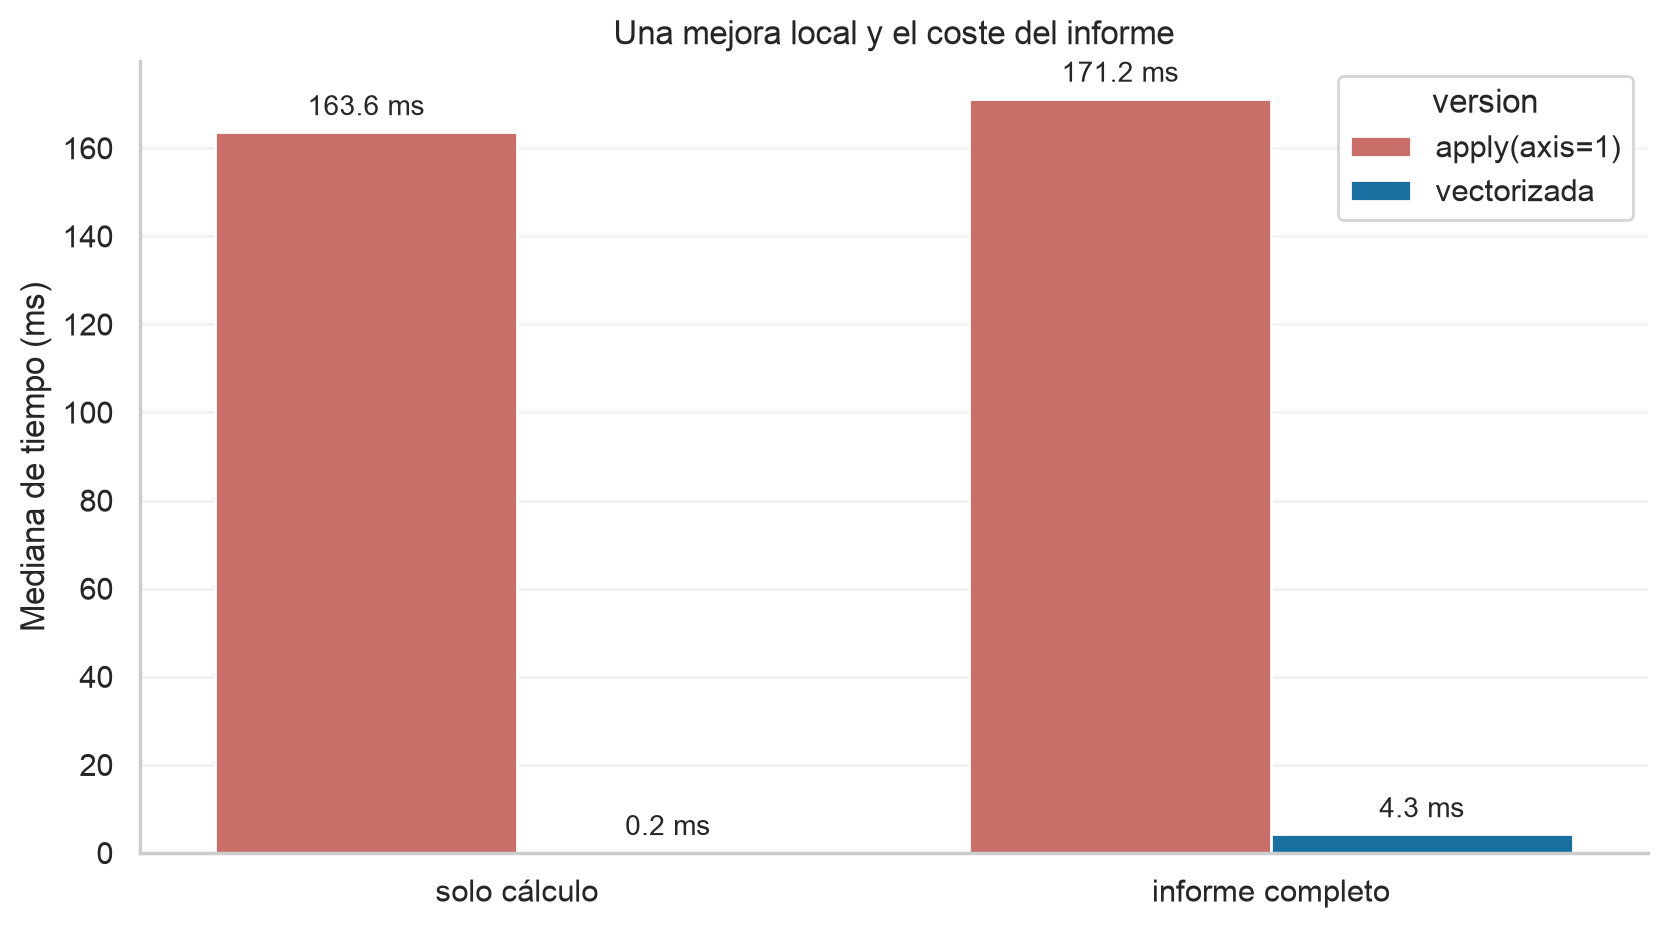

In [7]:
comparacion_alcance = [
    {'alcance': 'solo cálculo', 'version': 'apply(axis=1)', 'mediana_ms': medir(lambda: importe_lento(operaciones))['mediana_ms']},
    {'alcance': 'solo cálculo', 'version': 'vectorizada', 'mediana_ms': medir(lambda: importe_vectorizado(operaciones))['mediana_ms']},
    {'alcance': 'informe completo', 'version': 'apply(axis=1)', 'mediana_ms': baseline_lento['mediana_ms']},
    {'alcance': 'informe completo', 'version': 'vectorizada', 'mediana_ms': baseline_vectorizado['mediana_ms']},
]
graficar_comparacion(comparacion_alcance, 'Una mejora local y el coste del informe', grupo='alcance')

La optimización guiada ya está completa: identificamos el cuello de botella, cambiamos una sola cosa, volvimos a medir, visualizamos el impacto y verificamos el informe. Ahora aplicarás el mismo patrón a otra regla del pipeline.

## 6. Otro patrón lento: buscar repetidamente en una lista

Las reglas de control también pueden penalizar un pipeline. Aquí marcamos operaciones sensibles buscando cada identificador en una lista, y lo comparamos con Series.isin sobre un conjunto.

<positron-console-cell-8>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



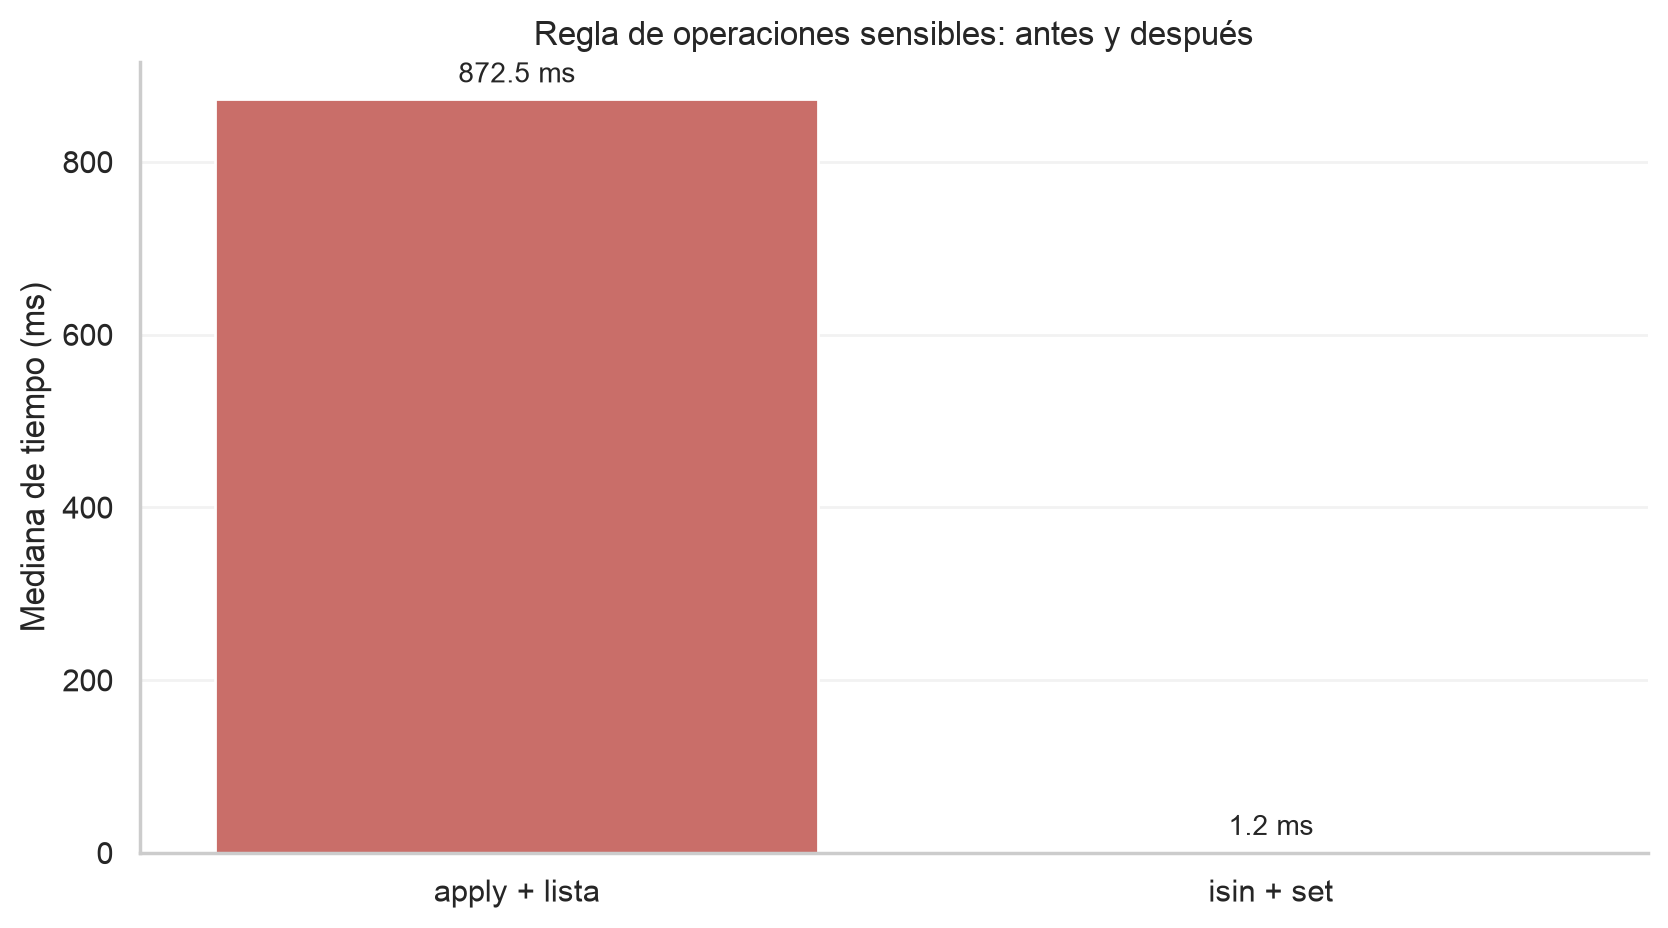

Speedup: 737.4x


In [8]:
operaciones_sensibles_lista = list(range(1, 3_001))
operaciones_sensibles_set = set(operaciones_sensibles_lista)

def marcar_sensibles_lento(datos):
    salida = datos.copy()
    salida['operacion_sensible'] = salida['operacion_id'].apply(lambda valor: valor in operaciones_sensibles_lista)
    return salida

def marcar_sensibles_isin(datos):
    salida = datos.copy()
    salida['operacion_sensible'] = salida['operacion_id'].isin(operaciones_sensibles_set)
    return salida

medida_lista = medir(lambda: marcar_sensibles_lento(operaciones))
medida_isin = medir(lambda: marcar_sensibles_isin(operaciones))
assert_frame_equal(marcar_sensibles_lento(operaciones), marcar_sensibles_isin(operaciones))
speedup_sensibles = medida_lista['mediana_ms'] / medida_isin['mediana_ms']
graficar_comparacion([{'version': 'apply + lista', 'mediana_ms': medida_lista['mediana_ms']}, {'version': 'isin + set', 'mediana_ms': medida_isin['mediana_ms']}], 'Regla de operaciones sensibles: antes y después')
print(f'Speedup: {speedup_sensibles:.1f}x')

# Práctica: acelerar una regla de prioridad

Operaciones quiere marcar como `alta` cualquier operación con importe igual o superior a 1.000 EUR, o realizada en `oficina`. La versión heredada funciona, pero vuelve a usar `apply(axis=1)`.

In [9]:
operaciones_con_importe = importe_vectorizado(operaciones)

def prioridad_lenta(datos):
    salida = datos.copy()
    salida['prioridad'] = salida.apply(
        lambda fila: 'alta' if fila['importe'] >= 1_000 or fila['canal'] == 'oficina' else 'normal',
        axis=1,
    )
    return salida

medida_prioridad_lenta = medir(lambda: prioridad_lenta(operaciones_con_importe))
print(f"Mediana regla lenta: {medida_prioridad_lenta['mediana_ms']:.1f} ms")

Mediana regla lenta: 122.4 ms


## Ejercicio 1 — Sustituir la regla fila a fila

Completa `prioridad_vectorizada()`. Construye primero la condición `es_alta` y usa `np.where` para asignar `alta` o `normal`. La función debe devolver una copia y no modificar la entrada.

In [10]:
def prioridad_vectorizada(datos):
    salida = datos.copy()
    # TODO: crea una máscara booleana con las dos condiciones de prioridad alta.
    es_alta = (salida['importe'] >= 1_000) | salida['canal'].eq('oficina')
    # TODO: usa np.where para crear la columna prioridad.
    salida['prioridad'] = np.where(es_alta, 'alta', 'normal')
    return salida

<details>
<summary><strong>Obtener esqueleto de ayuda para el ejercicio 1</strong></summary>

```python
def prioridad_vectorizada(datos):
    salida = datos.copy()
    es_alta = (salida['importe'] >= 1_000) | salida['canal'].eq('oficina')
    # TODO: asigna 'alta' cuando es_alta sea True y 'normal' en el resto.
    salida['prioridad'] = ...
    return salida
```
</details>

## Ejercicio 2 — Medir y comprobar la mejora

Mide tu versión vectorizada. Calcula el speedup como `mediana_lenta / mediana_vectorizada` y usa `assert_frame_equal` para comprobar que ambas funciones producen exactamente la misma tabla.

<positron-console-cell-11>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



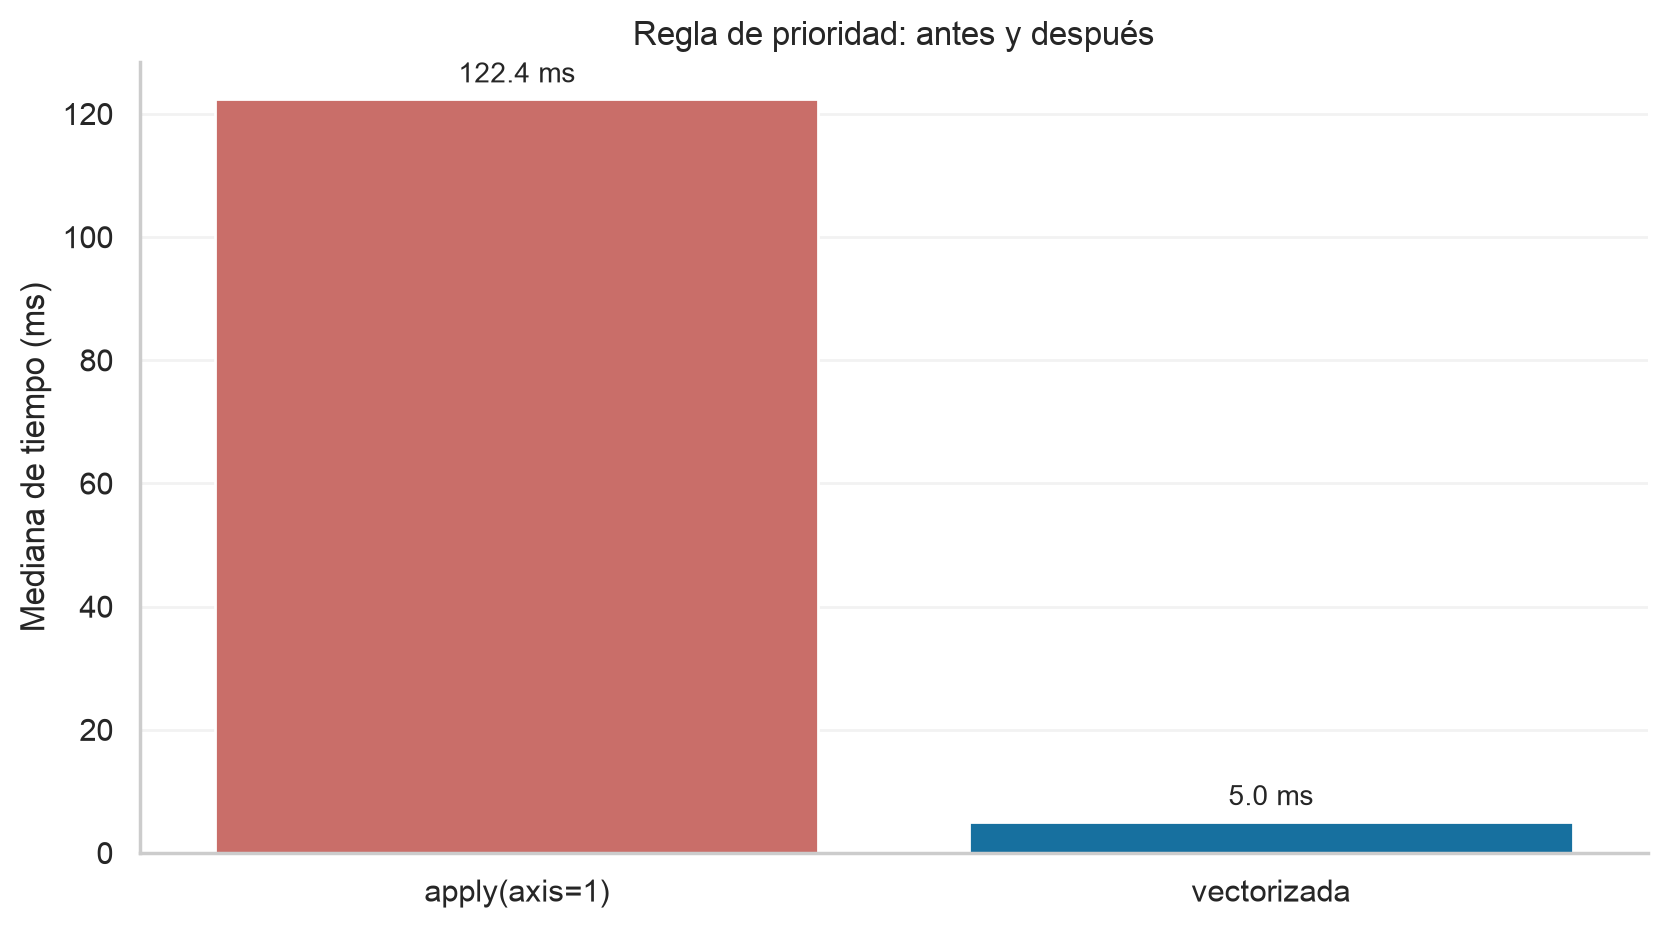

Speedup: 24.4x


In [11]:
# TODO: mide prioridad_vectorizada, calcula speedup y valida equivalencia.
medida_prioridad_vectorizada = medir(lambda: prioridad_vectorizada(operaciones_con_importe))
speedup_prioridad = medida_prioridad_lenta['mediana_ms'] / medida_prioridad_vectorizada['mediana_ms']
assert_frame_equal(prioridad_lenta(operaciones_con_importe), prioridad_vectorizada(operaciones_con_importe))
graficar_comparacion([{'version': 'apply(axis=1)', 'mediana_ms': medida_prioridad_lenta['mediana_ms']}, {'version': 'vectorizada', 'mediana_ms': medida_prioridad_vectorizada['mediana_ms']}], 'Regla de prioridad: antes y después')
print(f'Speedup: {speedup_prioridad:.1f}x')

<details>
<summary><strong>Obtener esqueleto de ayuda para el ejercicio 2</strong></summary>

```python
medida_prioridad_vectorizada = medir(lambda: prioridad_vectorizada(operaciones_con_importe))
speedup_prioridad = medida_prioridad_lenta['mediana_ms'] / medida_prioridad_vectorizada['mediana_ms']
# TODO: compara prioridad_lenta y prioridad_vectorizada con la misma entrada.
assert_frame_equal(..., ...)
print(f'Speedup: {speedup_prioridad:.1f}x')
```
</details>

## Ejercicio 3 — Recomendar, no solo acelerar

Completa el diccionario. La recomendación debe incluir la evidencia de rendimiento y confirmar que el resultado se ha validado. No proponemos todavía cambios de dtype, memoria o motor: serán el objeto del siguiente laboratorio.

In [12]:
recomendacion = {
    'cuello_de_botella': 'apply(axis=1) en la regla de prioridad',
    'mejora_aplicada': 'máscara booleana y np.where sobre Series completas',
    'speedup': round(float(speedup_prioridad), 2),
    'resultado_validado': True,
}
recomendacion

{'cuello_de_botella': 'apply(axis=1) en la regla de prioridad',
 'mejora_aplicada': 'máscara booleana y np.where sobre Series completas',
 'speedup': 24.43,
 'resultado_validado': True}

## Reto opcional — ¿crece la ventaja?

Repite la medición de prioridad lenta y vectorizada con 10.000, 50.000 100.000, 250.000 y 1.000.000 de filas. ¿En qué caso merece la pena medir también memoria antes de decidir?

## Preguntas abiertas

1. ¿Por qué un perfil es mejor punto de partida que una intuición?
2. ¿Qué garantiza `assert_frame_equal` y qué no garantiza?
3. ¿Qué costes del pipeline completo quedan fuera de esta sesión?